### Modeling Strategy
In this notebook, we will use Transformer based model to conduct news classification. Transformer does most of the heavy lifting by using tokenizers for most of the text preprocessing, and most of the manual processing like lowercasing, removing stop words, lemmatization, etc are not required. They learn the word embeddings contextually. The only preprocessing required here is to strip html tags and rest are taken care by the corresponding tokenizer of the transformer itself.

Transformer models are different from the traditional RNN models which process one token at a time. The Transformer model can access all the tokens using multihead attention and get a better understanding of the data by capturing relationships between words and phrases.

Here we will start with Bert models for the news classification task. Important information regarding the BERT based models
1. Bidirectional Encoder Representations from Transformers developed by Google.
2. Utilizes only the Encoder stack of the Transformer. But comes with a larger encoder structure. The original transformer used 6 encoder layars and 8 attention heads. BERT base comes with (12 encoders and 12 heads) and BERT large comes with (21 encoders and 16 heads). There are other variants as well.
3. BERT designers suggested that the masked multi head attention that masks rest of the sequence in the decoder impeded the attention process. 
4. Model was trained with 2 tasks:
   
    A masked multi head attention mask all the the sequences beyond the current position. This will prevent the  model from not seeing the output that it is supposed to predict. Basically this left to right approach learns a lot.  The authors trained the models from right to left and left to right (bidirectional manner). Most of these pretraining is unsupervised, unlabelled on large corpus of text and wikipedia data.
   1.  Masked language modeling: Introduced random mask on tokens in sentences for prediction. Added couple of things as well. Surprised the model by not masking single token on 10 % of dataset. Replaced a token with random token on 10 % of the dataset. Replace a token by mask token on 80% dataset. This would allow the model to learn in different ways.
   2.  Next sentence prediction: Input would be 2 sentences. In the 50% of the cases, the next sentence would be the actual sentence of the document. In the other 50 %, the second sentence is completely random and not related.
6. This allows BERT to learn complex relationships between tokens.

By pre-training on a large corpus
of text data, BERT can develop a deep understanding of the underlying structure and meaning of language, making it a highly effective tool for NLP tasks. Once pre-trained, BERT can be fine-tuned for downstream specific tasks, which allows it to adapt to the specific nuances of the task and improve its accuracy. In this notebooks, we will use the pretrained BERT model and fine tune it for the news classification purpose.

The input tokens to the models use the embeddings learned during the pretraining and it is stored in the embedding matrix. However, these embedding are not situation aware. For eg. bank in the river bank and savings bank have the same embedding. After the tokens are fed into the model, these embedding are converted into the final hidden states, which are contextual embedding. They have a better understanding of how each token is related to the other one depending on the whole sentence. In that case, 'bank' in the 'river bank' and 'savings bank' will have different embeddings.

The goal here is to feed the collect news data into the model and convert them into contextual representations. We will then use these representations to make further downstream classification.

In [31]:
import torch
from torch import nn, optim
import pandas as pd
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from transformers import BertTokenizer, BertModel, AdamW
from matplotlib import pyplot as plt

### Modeling with BERT
Since we aleady went through data preprocessing and exploratory data analysis, we will directly conduct the modeling in this notebook.

In [25]:
filepath = '../../data/data-final-cleaned-llm.csv'
df = pd.read_csv(filepath)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14262 entries, 0 to 14261
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Source       14262 non-null  object
 1   Category     14262 non-null  object
 2   Headline     14261 non-null  object
 3   Description  14262 non-null  object
 4   Link         14262 non-null  object
 5   Date         14262 non-null  object
 6   Author       14261 non-null  object
 7   Target       14262 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 891.5+ KB


In [21]:
df.iloc[:100, :].shape

(100, 8)

In [3]:
df.head(5)

,Source,Category,Headline,Description,Link,Date,Author,Target
0,Copperbelt Energy,economy news,CEC Career Opportunity: GDP – Legal,We currently have career opportunities in the ...,https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 16:31:18+00:00,Lovejoy Musundire,0
1,Copperbelt Energy,career,CEC Career Opportunity: Assurance Specialist –...,We currently have career opportunities in the ...,https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 15:15:28+00:00,Lovejoy Musundire,0
2,Copperbelt Energy,career,CEC Career Opportunity: Internal Auditor – In...,We currently have career opportunities in the ...,https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 15:14:39+00:00,Lovejoy Musundire,0
3,Copperbelt Energy,career,CEC Career Opportunity: Engineer – Protection,We currently have career opportunities in the ...,https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 15:13:41+00:00,Lovejoy Musundire,0
4,Copperbelt Energy,career,CEC Career Opportunity: Mechanic II,We currently have career opportunities in the ...,https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 15:13:05+00:00,Lovejoy Musundire,0


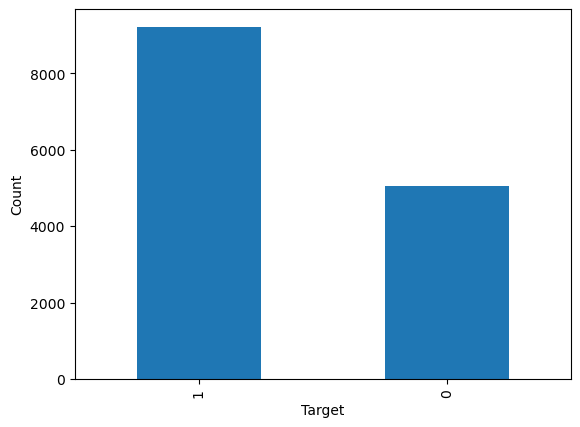

In [32]:
target = df['Target'].value_counts()
target.plot(kind='bar')
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

The tokenizer in the Transformer does lots of heavy lifting. There are some major things they do here.
1. Split the text to tokens which could be word, subwords and word pieces (subword tokenization algorithm). "unhappiness" >> "un", "##happiness", where # represents pre-existing words.
2. Then each token is mapped to the integer Id of the words in the model vocabulary. This integer Id is mapped to the word embedding in the model obtained during the training. This vector helps to understand the meaning and semantic realtionship between words.
3. Add special tokens like [CLS] (start of new sentece) and [SEP] (sentece separator) required by models like BERT.
4. Ensure consistency in sequence length using truncation of long sequences and padding of short sentences.
5. Also returns the attention masks: information on whether the token is actual or padded zeros.
6. Basicallly convert a text to set of intiger Ids of words and their attention mask values. Padded tokens have integer id:0
7. The BERT model takes in the input ids and their attention masks as input.

Let's take a look at a quick example:

In [4]:
text = df.loc[0, 'Headline']
print(text)

CEC Career Opportunity: GDP – Legal


In [5]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
print(inputs)

{'input_ids': tensor([[  101,  8292,  2278,  2476,  4495,  1024, 14230,  1516,  3423,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [6]:
print(tokenizer._tokenize(text))
print(tokenizer.vocab_size)
print(tokenizer.decode(inputs['input_ids'].flatten()))

['ce', '##c', 'career', 'opportunity', ':', 'gdp', '–', 'legal']
30522
[CLS] cec career opportunity : gdp – legal [SEP]


In [7]:
model = BertModel.from_pretrained("bert-base-uncased")

# Input text
text = "Excellent amazing great"

# Tokenize: return input_ids as PyTorch tensor
inputs = tokenizer(text, padding='max_length', truncation=True, return_tensors="pt")

#print(inputs)
print(tokenizer._tokenize(text))
#print(tokenizer.decode(inputs['input_ids'].flatten()))

# Pass through BERT model
with torch.no_grad():
    outputs = model(**inputs)

# Extract embeddings
last_hidden_state = outputs.last_hidden_state  # Shape: [batch_size, seq_len, hidden_dim]

#print(last_hidden_state.shape)
#print(last_hidden_state)
print(outputs.keys())

['excellent', 'amazing', 'great']
odict_keys(['last_hidden_state', 'pooler_output'])


#### Setting up the Dataset and Dataloader for training

In [8]:
# Let's define the dataset class now
# Make sure the __init_ class has access to all the data
# __getitem__ focusses on a single sample from the data defined in the __init__ class
# The returns of __getitem__ function should be a tensor as well.
# Otherwise collection of data in the batch throws an error


class NewsDataset(Dataset):
    def __init__(self, df, tokenizer):
        super().__init__()
        self.df = df
        self.text = self.df['Headline'] + self.df['Description']  # pandas dataframe
        self.labels = self.df['Target']
        self.tokenizer = tokenizer
        
    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, idx):
        text = self.text.iloc[idx]
        label = self.labels.iloc[idx]
        inputs = tokenizer(text, padding='max_length', truncation=True, return_tensors="pt")
        input_id = inputs['input_ids'].flatten()
        attention_mask = inputs['attention_mask'].flatten()
        return input_id, attention_mask, torch.tensor(label, dtype=torch.int64)

In [9]:
# Train, Validation and Test splitting of the data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=43, stratify=df['Target'])
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=43, stratify=test_df['Target'])
print(train_df.shape, val_df.shape, test_df.shape)

(11409, 8) (1426, 8) (1427, 8)


In [10]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

## Getting the dataset
## Dataset class allow the retrieval of features and labels one sample at a time
train_dataset = NewsDataset(train_df, tokenizer)
val_dataset = NewsDataset(val_df, tokenizer)
test_dataset = NewsDataset(test_df, tokenizer)

#Getting the dataloader
# Dataloader API will shuffle the data before each epoch and returns a minibatch of features and labels mentioned by the label size
# Basically collect several samples and convert that into a minibatch
# Here each batch will have 64 integer ids, their attention mask and class labels
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [11]:
x = train_dataset.__getitem__(1000)
print(x[2])
print(tokenizer.decode(x[0]))

tensor(0)
[CLS] zanaco launches new branch with customer experience high on the agenda6, 379 viewszanaco has launched a new branch that marks the bank ’ s fresh start in the way it will serve its more than one million customers. the new waterfalls branch, located at waterfalls shopping mall in lusaka, embodies how zanaco is changing the role of the branch, and how its layout underpins a renewal of the [ … ] the post zanaco launches new branch with customer experience high on the agenda first appeared on zambian eye. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD

In [12]:
for i, batch in enumerate(test_dataloader):
    if i==0:
        print(batch[0].shape, batch[1].shape, batch[2].shape)

torch.Size([64, 512]) torch.Size([64, 512]) torch.Size([64])


#### Some interesting things:
During the pretraining phase, the token embeddings are randomly initialized, so are the transformer weights. Depending on the context of the language, the token embeddings will get updated in each transformer layers. The token embeddings in each hidden layers are called hidden states. The hidden state of the final layers are used for further purposes.

For the classfication purposes, the hidden state of the CLS token in the last layer is used. This is because the CLS token is used to predict the next sentence and it is designed to act as a summary representation of the entire input sequence.During pretraining, BERT is trained to perform Next Sentence Prediction (NSP) using the [CLS] token's final layer output. Therefore BERT learns to encode global information into the [CLS] token. This aggregate representation captures semantic meaning of the full sequence.

The last hidden state in a BERT model contains the contextualized embeddings for each token in the input sequence — after passing through all Transformer layers. Each element in last_hidden_state is a vector of size hidden_size (e.g., 768 for bert-base). Each vector encodes the meaning of a token given its entire context (left and right). It is the result of multiple self-attention layers, so it understands the relationships between all tokens in the sentence.
For example:
"bank" in "he sat by the river bank" will get a vector different from "she went to the bank" — even though the token is the same — because of different context

How to do this: 
1. Either we can use the BertForSequence classfication which already has a classification head
2. output.pooler_output method - passes that CLS hidden state in the last layer through a dense (linear) layer followed by a Tanh activation.
3. Or get the last hidden state of CLS token and then feed it to drop out and linear layers to get the logits.

We will use the pooler_ouput method as it has some advantages. The tanh non-linear activation function, changes the output between -1 and 1 and allows faster convergence during optimization. Bounded output prevents the explosion of gradients and provides stability for downstream training. ReLU: Would discard all negative values, causing asymmetry and possibly losing signal. Sigmoid: Outputs only positive values (0 to 1), not centered at zero, and causes vanishing gradients. tanh: Smooth, zero-centered, bounded — the best middle ground for BERT’s needs.

#### What happens under the hood for transformers:
Transformers learn contextual awareness, i.e. it learns how each token is related other tokens in a general sense. Or basically try to understand different types of relationships between input tokens. So rather than using static token embeddings, transformers create different embeddings based on the context of the full sequence.
Steps:
1. Tokenizing the input sequence and mapping the corresponding token id to a vector embedding (obtained from the pretraining).
2. Plus positional embedding are added to the vector embedding to understand the word order.
3. Now the transformer layers:
   a. Multi head attention: Different multihead attention tries to understand different relationships between tokens. These are done using Query, Key and Value vectors which are projections of the input embedding. Basically each token attends to all other tokens. This calculates the attention score of each head learning a different contextual representation in parallel. This wil allow to learn different relationship between tokens. If the query and key are related, then the attention score would be high. This t*t representation will show which token is related to the other ones. Then a softmax is used to get the attention weights which would add upto 1. This is multiplied with the value vector to get the contextual representations.
   b. Finally each token embeddings sepearately goes through a feed forward layer to get the output representation.
   c. Additionally there will be a residual connection and batch normalization to for reducing the noise, improving gradient flow and training stability.
4. Final output would be a contextual embedding for each token. ie: flies in "time flies" and "fruit flies" will have different contextual embeddings.
Early layers capture syntax; deeper layers capture semantics.

In [13]:
# Lets define the model class
class BertClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name) # The model will output would be [batch_size, sequence_length, hidden_states]
        # hidden_states = 768 for the base model
        self.dropout = nn.Dropout(0.1)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask) # [batch_size, sequence_length, hidden_states]
        # Now we need to collect the hidden state of CLS (first) token
        # cls_hidden_state = output[:,0,:] # calling the first token
        # pooler output = tanh(dense(cls_hidden_state))
        pooler = output.pooler_output
        drop = self.dropout(pooler)
        logits = self.fc(drop)
        return logits

In [22]:
device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"
print(f"Using {device}")
#device = "cpu"

learning_rate = 3e-4
epochs =  2

# Calling the model here, load everything to device. Do not initialize in the cpu and then load it to the GPU.
model = BertClassifier("bert-base-uncased", 2).to(device)

# defining the loss function and optimizer 
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

Using mps


In [23]:
for name, param in model.bert.named_parameters():
    print(name)

embeddings.word_embeddings.weight
embeddings.position_embeddings.weight
embeddings.token_type_embeddings.weight
embeddings.LayerNorm.weight
embeddings.LayerNorm.bias
encoder.layer.0.attention.self.query.weight
encoder.layer.0.attention.self.query.bias
encoder.layer.0.attention.self.key.weight
encoder.layer.0.attention.self.key.bias
encoder.layer.0.attention.self.value.weight
encoder.layer.0.attention.self.value.bias
encoder.layer.0.attention.output.dense.weight
encoder.layer.0.attention.output.dense.bias
encoder.layer.0.attention.output.LayerNorm.weight
encoder.layer.0.attention.output.LayerNorm.bias
encoder.layer.0.intermediate.dense.weight
encoder.layer.0.intermediate.dense.bias
encoder.layer.0.output.dense.weight
encoder.layer.0.output.dense.bias
encoder.layer.0.output.LayerNorm.weight
encoder.layer.0.output.LayerNorm.bias
encoder.layer.1.attention.self.query.weight
encoder.layer.1.attention.self.query.bias
encoder.layer.1.attention.self.key.weight
encoder.layer.1.attention.self.key

In [ ]:
train_losses = []
val_losses = []

# Train the model here
for e in range(epochs):
    model.train()
    train_running_loss = 0
    for input_ids, attention_masks, labels in tqdm(train_dataloader):
        # collect the data in each batch 
        # loading all the data to device
        #print(device)

        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        # feed forward part of the model
        # This will basically output the logits [batch, class]
        ypred = model(input_ids=input_ids, attention_mask=attention_masks)

        # zeros the gradients in each batch, otherwise they will accumulate. Because gradient needs to be calculate wrt to the loss of each batch.
        optimizer.zero_grad()

        #calculate the cross entropy loss
        loss = criterion(ypred, labels) 

        train_running_loss += loss.item() # converting torch to scalar

        # backpropogation
        loss.backward() # calculate the gradient of the loss wrt each parameter and update the parameter.grad field

        # Update the weights, current parameter - (learning rate * parameter.grad)
        optimizer.step()

        # delete unnecessary data in memory
        del input_ids, attention_masks, ypred, loss

        # empty unused cache
        torch.mps.empty_cache()

    train_loss = train_running_loss/len(train_dataloader)
    train_losses.append(train_loss)


    # Set the model to the evaluatio mode
    model.eval()
    val_running_loss = 0
    with torch.no_grad(): # no need to create the compuatational graph
        for input_ids, attention_masks, labels in tqdm(val_dataloader):
            # collect the data in each batch 
            input_ids, attention_masks, labels = batch
    
            # loading all the data to device
            # Whenever you load the data or model, load them directly onto the device. Do not initialize them locally in cpu memory and then load it to the 
            # GPU memory. That causes lots of confusions. Then it look like the data is not initialized in the memory.
            input_ids = input_ids.to(device)
            attention_masks = attention_masks.to(device)
            labels = labels.to(device)
    
            # feed forward part of the model
            # This will basically output the logits [batch, class]
            ypred = model(input_ids=input_ids, attention_mask=attention_masks)
    
    
            #calculate the binary cross entropy loss
            loss = criterion(ypred, labels) 
    
            val_running_loss += loss.item() # converting torch to scalar

            del input_ids, attention_masks, ypred

            # empty unused cache
            torch.mps.empty_cache()
        
        val_loss = val_running_loss/len(val_dataloader)
        val_losses.append(val_loss)

    # print statistics across each epoch
    print("*"*30)
    print(f"Epoch: {e}")
    print(f"Train loss: {train_loss: 0.4f}")
    print(f"Validation loss: {val_loss: 0.4f}")
    print("*"*30)